# A Comparative Study of Extractive and Abstractive Text Summarization Techniques
### Data Mining Project Report

**Dataset:** BBC News Summary (Kaggle) - 2,225 news articles across five categories
(business, entertainment, politics, sport, technology), each paired with a human-written
reference summary.

**Objective:** To implement and empirically compare nine text summarization approaches
spanning four methodological families - statistical/graph-based extractive methods,
clustering-based extractive methods, supervised classification-based extractive methods,
and deep learning-based abstractive summarization and to evaluate their performance
using the ROUGE metric suite and computational runtime.

---


## 1. Data Acquisition and Loading

The dataset used is the **BBC News Summary** corpus, obtained from Kaggle
(`pariza/bbc-news-summary`) via the `kagglehub` library, which programmatically
downloads and caches the dataset locally. The corpus consists of plain-text news
articles organized into five category folders, each with a corresponding folder of
human-authored reference summaries sharing identical filenames.

The data loading procedure is as follows:
1. Download and cache the dataset locally using `kagglehub.dataset_download()`.
2. Verify the folder structure (`News Articles/<category>/`, `Summaries/<category>/`)
   using directory traversal.
3. Iterate through every category and file, reading each article and its matching
   reference summary, and compile the results into a structured `pandas` DataFrame
   with columns `category`, `filename`, `article`, and `summary`.

This DataFrame (`df`) forms the foundation for all subsequent preprocessing, feature
extraction, modeling, and evaluation stages of the project.


In [1]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("pariza/bbc-news-summary")
print(path)

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.37-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.37-py3-none-any.whl (262 kB)
Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl (439 kB)



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
e:\Sign_Train_First\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2


In [3]:
import os

base_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2"

for root, dirs, files in os.walk(base_path):
    print(root, "->", len(files), "files")

C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2 -> 0 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary -> 0 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\BBC News Summary -> 0 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\BBC News Summary\News Articles -> 0 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\BBC News Summary\News Articles\business -> 510 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\BBC News Summary\News Articles\entertainment -> 386 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\BBC News Summary\News Articles\politics -> 417 files
C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\BBC News 

In [4]:
articles_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\News Articles"

# list files in the 'business' category
business_files = os.listdir(os.path.join(articles_path, "business"))
print(business_files[:5])   # show first 5 filenames

# open and print the very first article
first_file = os.path.join(articles_path, "business", business_files[0])
with open(first_file, 'r', encoding='latin-1') as f:
    content = f.read()

print(content)

['001.txt', '002.txt', '003.txt', '004.txt', '005.txt']
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to 

In [6]:
summaries_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\Summaries"

first_summary_file = os.path.join(summaries_path, "business", business_files[0])  # same filename, different folder
with open(first_summary_file, 'r', encoding='latin-1') as f:
    summary_content = f.read()

print(summary_content)

TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.Time Warner's fourth quarter profits were slightly better than analysts' expectations.


In [7]:
import pandas as pd

articles_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\News Articles"
summaries_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\pariza\bbc-news-summary\versions\2\BBC News Summary\Summaries"

categories = os.listdir(articles_path)
print("Categories:", categories)

records = []
for category in categories:
    article_dir = os.path.join(articles_path, category)
    summary_dir = os.path.join(summaries_path, category)

    for filename in os.listdir(article_dir):
        article_file = os.path.join(article_dir, filename)
        summary_file = os.path.join(summary_dir, filename)

        with open(article_file, 'r', encoding='latin-1') as f:
            article_text = f.read()

        with open(summary_file, 'r', encoding='latin-1') as f:
            summary_text = f.read()

        records.append({
            'category': category,
            'filename': filename,
            'article': article_text,
            'summary': summary_text
        })

df = pd.DataFrame(records)
print(df.shape)
df.head()

Categories: ['business', 'entertainment', 'politics', 'sport', 'tech']
(2225, 4)


,category,filename,article,summary
0,business,001.txt,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,business,002.txt,Dollar gains on Greenspan speech\n\nThe dollar...,The dollar has hit its highest level against t...
2,business,003.txt,Yukos unit buyer faces loan claim\n\nThe owner...,Yukos' owner Menatep Group says it will ask Ro...
3,business,004.txt,High fuel prices hit BA's profits\n\nBritish A...,"Rod Eddington, BA's chief executive, said the ..."
4,business,005.txt,Pernod takeover talk lifts Domecq\n\nShares in...,Pernod has reduced the debt it took on to fund...


## 2. Exploratory Data Analysis

Prior to preprocessing, the dataset was examined for data quality and structural
characteristics. This included checks for missing or empty article/summary fields,
verification of class balance across the five news categories, and descriptive
statistics on article and summary length (measured in word count). This step
establishes a baseline understanding of the dataset's characteristics including an
implicit estimate of the typical compression ratio between article and summary length
which informs downstream design decisions such as target summary length.


In [8]:
# any missing or empty values?
print(df.isnull().sum())
print()
print("Empty articles:", (df['article'].str.strip() == '').sum())
print("Empty summaries:", (df['summary'].str.strip() == '').sum())
print()

# category balance
print(df['category'].value_counts())
print()

# article and summary length (in words)
df['article_len'] = df['article'].apply(lambda x: len(x.split()))
df['summary_len'] = df['summary'].apply(lambda x: len(x.split()))

print(df[['article_len', 'summary_len']].describe())

category    0
filename    0
article     0
summary     0
dtype: int64

Empty articles: 0
Empty summaries: 0

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

       article_len  summary_len
count  2225.000000  2225.000000
mean    384.040449   165.166742
std     238.174497   108.655971
min      89.000000    38.000000
25%     246.000000   103.000000
50%     332.000000   142.000000
75%     471.000000   202.000000
max    4432.000000  2073.000000


## 3. Sentence Tokenization

All extractive summarization methods evaluated in this study operate at the sentence
level: they score and select whole sentences rather than individual words. Sentence
tokenization was performed using NLTK's `sent_tokenize`, which employs a pretrained
(Punkt) sentence-boundary detection model capable of correctly distinguishing
sentence-terminal punctuation from other uses of the period (e.g., abbreviations such
as "Mr." or "U.S."), which a naive delimiter-based split would fail to handle
correctly.


In [9]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

sample_article = df.iloc[0]['article']
sentences = sent_tokenize(sample_article)

print(f"Number of sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i}: {s}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Number of sentences: 20
0: Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.
1: The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales.
2: TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.
3: Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.
4: Time Warner said on Friday that it now owns 8% of search-engine Google.
5: But its own internet business, AOL, had has mixed fortunes.
6: It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.
7: However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.
8: It hopes to increase subscribers by offering the online service free to TimeWar

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 4. Headline and Body Separation

Inspection of the raw article files revealed that each file begins with a headline on
its own line, followed by the article body. Tokenizing the full, undifferentiated file
into sentences would incorrectly treat the headline as an ordinary sentence, which
distorts sentence-scoring features introduced later in the pipeline (particularly
headline-similarity features).

A `split_title_and_body` function was implemented to separate the first line (title)
from the remainder (body) of each article. This function was applied across the entire
dataset, after which sentence tokenization was performed on the article **body** only.
The resulting `title`, `sentences`, and `num_sentences` fields were added to the
DataFrame for use in subsequent stages.


In [10]:
def split_title_and_body(article_text):
    parts = article_text.split('\n', 1)  # split on the FIRST newline only
    title = parts[0].strip()
    body = parts[1].strip() if len(parts) > 1 else ""
    return title, body

# test on the same sample article
title, body = split_title_and_body(df.iloc[0]['article'])
print("TITLE:", title)
print()
print("BODY (first 200 chars):", body[:200])

TITLE: Ad sales boost Time Warner profit

BODY (first 200 chars): Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google,


In [11]:
sentences = sent_tokenize(body)

print(f"Number of sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i}: {s}")
    

Number of sentences: 20
0: Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.
1: The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales.
2: TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.
3: Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.
4: Time Warner said on Friday that it now owns 8% of search-engine Google.
5: But its own internet business, AOL, had has mixed fortunes.
6: It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.
7: However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.
8: It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try

In [12]:
def split_title_and_body(article_text):
    parts = article_text.split('\n', 1)
    title = parts[0].strip()
    body = parts[1].strip() if len(parts) > 1 else ""
    return title, body

# apply to every row
titles = []
bodies = []
for article_text in df['article']:
    title, body = split_title_and_body(article_text)
    titles.append(title)
    bodies.append(body)

df['title'] = titles
df['body'] = bodies

# now tokenize each body into sentences
df['sentences'] = df['body'].apply(sent_tokenize)

# quick check
print(df[['title', 'sentences']].iloc[0])
print()
print("Number of sentences per article - summary stats:")
df['num_sentences'] = df['sentences'].apply(len)
print(df['num_sentences'].describe())

title                        Ad sales boost Time Warner profit
sentences    [Quarterly profits at US media giant TimeWarne...
Name: 0, dtype: object

Number of sentences per article - summary stats:
count    2225.000000
mean       18.608090
std        12.719021
min         4.000000
25%        12.000000
50%        16.000000
75%        22.000000
max       248.000000
Name: num_sentences, dtype: float64


## 5. Character Encoding Correction

The source text files were found to contain UTF-8 byte sequences that had been
incorrectly interpreted as Latin-1 encoding during initial reading, producing
mojibake artifacts in punctuation characters (e.g., curly quotes, em-dashes). This is
a common issue with legacy British news text archives.

A corrective encode/decode round-trip procedure was applied: each string was
re-encoded as raw Latin-1 bytes and then correctly decoded as UTF-8, with a fallback to
the original text where this conversion was not applicable. This correction is
necessary because encoding artifacts fragment the TF-IDF vocabulary and distort term
frequency statistics used throughout the subsequent feature extraction and modeling
stages.


In [13]:
def fix_encoding(text):
    try:
        return text.encode('latin-1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text  # if it fails, leave the text as-is

# test it on the sample article first
sample_text = df.iloc[0]['article']
print("BEFORE:")
print(sample_text[:300])
print()
print("AFTER:")
print(fix_encoding(sample_text)[:300])

BEFORE:
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and high

AFTER:
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and highe


In [14]:
# apply encoding fix to article and summary columns
df['article'] = df['article'].apply(fix_encoding)
df['summary'] = df['summary'].apply(fix_encoding)

# re-run title/body split and sentence tokenization on the CLEANED text
titles = []
bodies = []
for article_text in df['article']:
    title, body = split_title_and_body(article_text)
    titles.append(title)
    bodies.append(body)

df['title'] = titles
df['body'] = bodies
df['sentences'] = df['body'].apply(sent_tokenize)
df['num_sentences'] = df['sentences'].apply(len)

print(df[['title', 'body']].iloc[0]['body'][:300])

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fou


## 6. Text Preprocessing: Stopword Removal and Lemmatization

Standard NLP preprocessing was applied to each sentence prior to vectorization,
comprising three operations:

1. **Normalization** - removal of non-alphabetic characters and case-folding to
   lowercase, ensuring consistent token representation.
2. **Stopword removal** - elimination of high-frequency function words (e.g., "the",
   "is", "and") that carry minimal topical or discriminative information but occur in
   nearly every sentence, which would otherwise dilute frequency-based importance
   measures.
3. **Lemmatization** - reduction of words to their canonical dictionary form (e.g.,
   "running" → "run") using WordNet's lemmatizer, so that morphological variants of the
   same concept are treated as a single feature rather than distinct ones.

The cleaned sentence text (`clean_sentences`) is used exclusively for feature
extraction and vectorization; the original, unprocessed sentence text is retained
separately and used for constructing human-readable output summaries.


In [15]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_sentence(sentence):
    # keep only letters and spaces, lowercase everything
    sentence = re.sub(r'[^a-zA-Z\s]', '', sentence)
    sentence = sentence.lower()
    
    words = sentence.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return ' '.join(words)

# test on one sentence from the sample article
test_sentence = df.iloc[0]['sentences'][0]
print("BEFORE:", test_sentence)
print("AFTER: ", clean_sentence(test_sentence))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


BEFORE: Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.
AFTER:  quarterly profit u medium giant timewarner jumped bn three month december yearearlier


In [16]:
df['clean_sentences'] = df['sentences'].apply(lambda sent_list: [clean_sentence(s) for s in sent_list])

# sanity check
print(df.iloc[0]['clean_sentences'][:3])

['quarterly profit u medium giant timewarner jumped bn three month december yearearlier', 'firm one biggest investor google benefited sale highspeed internet connection higher advert sale', 'timewarner said fourth quarter sale rose bn bn']


## 7. Term Frequency-Inverse Document Frequency (TF-IDF) and Cosine Similarity

**TF-IDF** was used to convert each sentence into a numerical vector representation.
The TF-IDF weight of a term combines its frequency within a given sentence (Term
Frequency) with an inverse measure of how commonly that term occurs across all
sentences in the article (Inverse Document Frequency). This weighting scheme assigns
higher importance to terms that are frequent within a specific sentence but rare
elsewhere in the document, capturing lexical distinctiveness.

**Cosine similarity** was used to quantify the similarity between two sentence
vectors, computed as the cosine of the angle between them (range: 0 to 1, independent
of vector magnitude). This measure underlies two subsequent components of the
pipeline: (i) scoring each sentence's similarity to the article's overall centroid
vector, and (ii) constructing the sentence-similarity graph used by the TextRank
algorithm.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# test on the sample article's clean sentences
sample_clean = df.iloc[0]['clean_sentences']

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sample_clean)

print("Shape:", tfidf_matrix.shape)  # (num_sentences, num_unique_words)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("First 10 words in vocabulary:", vectorizer.get_feature_names_out()[:10])

Shape: (20, 163)
Vocabulary size: 163
First 10 words in vocabulary: ['account' 'adjust' 'advert' 'advertising' 'alexander' 'already' 'also'
 'amount' 'analyst' 'aol']


In [18]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_matrix)

print("Shape:", sim_matrix.shape)  # should be (num_sentences, num_sentences)
print()
print("Similarity of sentence 0 to itself:", sim_matrix[0][0])
print("Similarity of sentence 0 to sentence 1:", sim_matrix[0][1])

Shape: (20, 20)

Similarity of sentence 0 to itself: 1.0
Similarity of sentence 0 to sentence 1: 0.0


## 8. Sentence-Level Feature Engineering

Four features were engineered for each sentence to support both extractive scoring
and, later, supervised classification:

| Feature | Description | Rationale |
|---|---|---|
| `position` | Sentence index within the article | News articles follow an "inverted pyramid" structure; earlier sentences are more likely to contain salient information. |
| `length` | Word count of the sentence | Extremely short sentences tend to carry less standalone informational content. |
| `centroid_sim` | Cosine similarity to the article's mean TF-IDF vector | High similarity to the article's overall vocabulary distribution indicates thematic centrality. |
| `title_sim` | Cosine similarity to the article's title | Headlines function as human-authored micro-summaries; sentences that echo the headline's vocabulary are likely to be central to the article's main point. |

These features were computed for every sentence across the full dataset and
consolidated into a single feature table (`features_df`), indexed by article, for use
in both the TF-IDF summarizer and the supervised classification models developed in
later sections.


In [19]:
import numpy as np

def get_sentence_features(clean_sentences, title):
    # fit TF-IDF including the title, so title similarity is comparable
    all_texts = clean_sentences + [clean_sentence(title)]
    
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform(all_texts)
    
    sentence_vectors = tfidf[:-1]   # all rows except the last (which is the title)
    title_vector = tfidf[-1]        # last row = title
    
    centroid = np.asarray(sentence_vectors.mean(axis=0))  # average of all sentence vectors
    
    centroid_sim = cosine_similarity(sentence_vectors, centroid).flatten()
    title_sim = cosine_similarity(sentence_vectors, title_vector).flatten()
    
    position = list(range(len(clean_sentences)))
    length = [len(s.split()) for s in clean_sentences]
    
    return pd.DataFrame({
        'position': position,
        'length': length,
        'centroid_sim': centroid_sim,
        'title_sim': title_sim
    })

# test on sample article
sample_features = get_sentence_features(df.iloc[0]['clean_sentences'], df.iloc[0]['title'])
print(sample_features.head())

   position  length  centroid_sim  title_sim
0         0      12      0.333610   0.046794
1         1      13      0.275657   0.154453
2         2       8      0.486919   0.109930
3         3      12      0.297628   0.171579
4         4       7      0.274304   0.251802


In [20]:
all_features = []

for idx, row in df.iterrows():
    feats = get_sentence_features(row['clean_sentences'], row['title'])
    feats['article_idx'] = idx  # keep track of which article each row belongs to
    all_features.append(feats)

features_df = pd.concat(all_features, ignore_index=True)
print(features_df.shape)
print(features_df.head())

(41403, 5)
   position  length  centroid_sim  title_sim  article_idx
0         0      12      0.333610   0.046794            0
1         1      13      0.275657   0.154453            0
2         2       8      0.486919   0.109930            0
3         3      12      0.297628   0.171579            0
4         4       7      0.274304   0.251802            0


## 9. Method 1 - TF-IDF Centroid-Based Extractive Summarization

This method ranks each article's sentences by their `centroid_sim` score (Section 8)
and selects the top-N highest-scoring sentences as the summary. Selected sentences are
subsequently re-ordered according to their original position in the article prior to
output, preserving narrative coherence in the final summary — a standard convention in
extractive summarization: selection is performed by importance ranking, but
presentation follows original document order.


In [61]:
def tfidf_summarize_wrapper(article_idx, df, num_sentences=3):
    return tfidf_summarize(article_idx, features_df, df, num_sentences=num_sentences) 

In [59]:
def tfidf_summarize(article_idx, features_df, df, num_sentences=3):
    # get this article's sentence features
    article_feats = features_df[features_df['article_idx'] == article_idx].copy()
    
    # rank by centroid similarity, take top N
    top_sentences = article_feats.sort_values('centroid_sim', ascending=False).head(num_sentences)
    
    # sort back into original order for readability
    top_sentences = top_sentences.sort_values('position')
    
    # pull the actual (uncleaned) sentence text
    original_sentences = df.loc[article_idx, 'sentences']
    return [original_sentences[i] for i in top_sentences['position']]
    

# test on sample article
summary = tfidf_summarize(0, features_df, df, num_sentences=3)
print("GENERATED SUMMARY:")
print(summary)
print()
print("REFERENCE SUMMARY:")
print(df.iloc[0]['summary'])

GENERATED SUMMARY:
['TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.', "However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.", 'For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.']

REFERENCE SUMMARY:
TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting op

## 10. Method 2 - TextRank (Graph-Based Extractive Summarization)

TextRank is a graph-based ranking algorithm adapted from Google's PageRank, originally
designed to rank web pages by inbound link structure. Applied to sentence-level
summarization:

- Each sentence is represented as a node in an undirected graph.
- Edge weights between nodes correspond to the cosine similarity between the
  respective sentence TF-IDF vectors.
- The PageRank algorithm is applied to this similarity graph, assigning each sentence
  an importance score that increases with its similarity to other high-scoring
  sentences, rather than to the document as a whole.

This produces a distinct notion of sentence importance compared to the centroid-based
TF-IDF method (Section 9): TextRank identifies sentences that are corroborated by
multiple other sentences with related content, whereas the centroid method identifies
sentences representative of the document's overall vocabulary distribution. The
resulting rankings frequently diverge, forming the basis for comparative analysis in
Section 11.


In [60]:
import networkx as nx

def textrank_summarize(article_idx, df, num_sentences=3):
    clean_sents = df.loc[article_idx, 'clean_sentences']
    original_sents = df.loc[article_idx, 'sentences']
    
    # build TF-IDF + similarity matrix for this article (same as Step 5-6)
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform(clean_sents)
    sim_matrix = cosine_similarity(tfidf)
    
    # build a graph where edge weight = similarity between two sentences
    graph = nx.from_numpy_array(sim_matrix)
    
    # run PageRank
    scores = nx.pagerank(graph)
    
    # rank sentences by PageRank score, take top N
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_indices = [idx for idx, score in ranked[:num_sentences]]
    
    # sort back into original order
    top_indices.sort()

    return [original_sents[i] for i in top_indices]

# test on sample article
summary = textrank_summarize(0, df, num_sentences=3)
print("TEXTRANK SUMMARY:")
print(summary)
print()
print("REFERENCE SUMMARY:")
print(df.iloc[0]['summary'])

TEXTRANK SUMMARY:
['TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.', "However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.", 'For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.']

REFERENCE SUMMARY:
TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting ope

## 11. Comparative Ranking Analysis: TF-IDF vs. TextRank

To directly compare the two ranking methods, both were applied to a longer,
structurally complex article, and their top-10 sentence rankings were tabulated
side by side. This comparison provides empirical evidence for the qualitative
differences between the two scoring approaches, supporting the discussion of
methodological trade-offs presented in the results and discussion sections of this
report.


In [23]:
# find a longer article to test on
longer_idx = df[df['num_sentences'] > 30].index[0]
print("Testing on article index:", longer_idx, "-", df.loc[longer_idx, 'title'])
print("Number of sentences:", df.loc[longer_idx, 'num_sentences'])
print()

print("TF-IDF SUMMARY:")
# reuse tfidf_summarize from Step 9
print(tfidf_summarize(longer_idx, features_df, df, num_sentences=3))
print()

print("TEXTRANK SUMMARY:")
print(textrank_summarize(longer_idx, df, num_sentences=3))
print()

print("REFERENCE SUMMARY:")
print(df.loc[longer_idx, 'summary'])

Testing on article index: 145 - Why few targets are better than many
Number of sentences: 47

TF-IDF SUMMARY:
Mr Kok was commissioned by the European Commission in March this year to assess how far the EU has come towards meeting the Lisbon targets, five years on from their inception. "Lisbon is about everything and thus about nothing," the Kok report said. That's why the Kok report recommends that the Lisbon targets be narrowed down to 14 key indicators, with an emphasis on creating jobs and economic growth.

TEXTRANK SUMMARY:
Mr Kok was commissioned by the European Commission in March this year to assess how far the EU has come towards meeting the Lisbon targets, five years on from their inception. "Lisbon is about everything and thus about nothing," the Kok report said. That's why the Kok report recommends that the Lisbon targets be narrowed down to 14 key indicators, with an emphasis on creating jobs and economic growth.

REFERENCE SUMMARY:
That's why the Kok report recommends that

In [24]:
# get full rankings from both methods on this article
clean_sents = df.loc[longer_idx, 'clean_sentences']

# TF-IDF centroid scores (from features_df)
article_feats = features_df[features_df['article_idx'] == longer_idx].copy()
tfidf_ranking = article_feats.sort_values('centroid_sim', ascending=False)[['position', 'centroid_sim']].head(10)

# TextRank scores (recompute, same as inside textrank_summarize)
vectorizer = TfidfVectorizer()
tfidf_mat = vectorizer.fit_transform(clean_sents)
sim_matrix = cosine_similarity(tfidf_mat)
graph = nx.from_numpy_array(sim_matrix)
pagerank_scores = nx.pagerank(graph)
textrank_ranking = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("TOP 10 BY TF-IDF CENTROID SIMILARITY:")
print(tfidf_ranking)
print()
print("TOP 10 BY TEXTRANK (PAGERANK):")
for idx, score in textrank_ranking:
    print(f"position {idx}: {score:.4f}")

TOP 10 BY TF-IDF CENTROID SIMILARITY:
      position  centroid_sim
2123         5      0.368512
2148        30      0.361332
2146        28      0.347547
2118         0      0.342986
2119         1      0.331317
2159        41      0.308308
2153        35      0.290370
2129        11      0.285958
2155        37      0.282795
2152        34      0.281185

TOP 10 BY TEXTRANK (PAGERANK):
position 5: 0.0313
position 30: 0.0309
position 28: 0.0307
position 0: 0.0298
position 1: 0.0283
position 41: 0.0280
position 34: 0.0256
position 35: 0.0253
position 11: 0.0248
position 37: 0.0245


## 12. Method 3 - K-Means Clustering: Determination of Optimal Cluster Count

**K-Means clustering** partitions an article's sentences into *k* groups based on
their TF-IDF vector representations, such that sentences within a cluster are more
similar to one another than to sentences in other clusters. In the context of
summarization, each cluster is assumed to correspond to a distinct sub-topic within
the article; selecting one representative sentence per cluster yields a summary with
broad topical coverage rather than redundant emphasis on a single theme.

Since K-Means requires the number of clusters to be specified a priori, the **elbow
method** was used to identify an appropriate value of *k*. This method plots inertia
(the sum of squared distances between points and their assigned cluster centroids)
against increasing values of *k*; the point at which additional clusters yield
diminishing reduction in inertia - the "elbow" - indicates a reasonable cluster count.
This analysis was performed across three articles of varying length to assess the
stability of the optimal *k* across different document sizes.


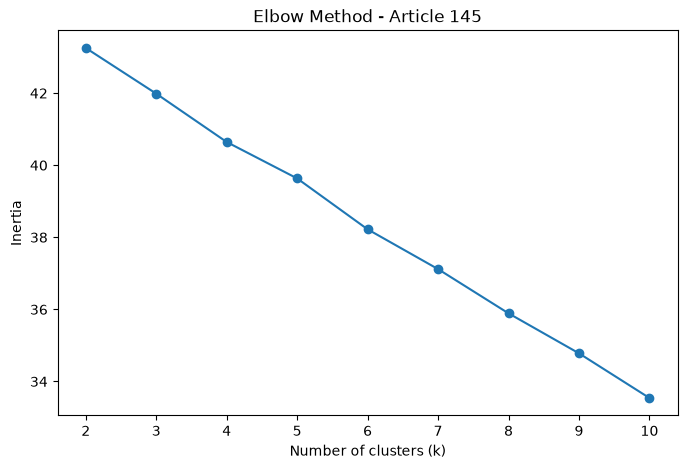

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# use the same longer article (145) to test the elbow method
clean_sents = df.loc[longer_idx, 'clean_sentences']

vectorizer = TfidfVectorizer()
tfidf_mat = vectorizer.fit_transform(clean_sents)

inertias = []
k_range = range(2, 11)  # test k from 2 to 10

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_mat)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title(f'Elbow Method - Article {longer_idx}')
plt.show()

In [26]:
# pick 2 more articles of different lengths to compare
test_indices = [longer_idx]  # article 145, already have this one

# add a short article and a very long one for contrast
short_idx = df[df['num_sentences'].between(10, 15)].index[0]
very_long_idx = df[df['num_sentences'] > 60].index[0]

test_indices += [short_idx, very_long_idx]

print("Testing on articles:", test_indices)
for idx in test_indices:
    print(f"  {idx}: {df.loc[idx, 'num_sentences']} sentences - {df.loc[idx, 'title']}")

Testing on articles: [np.int64(145), np.int64(1), np.int64(640)]
  145: 47 sentences - Why few targets are better than many
  1: 15 sentences - Dollar gains on Greenspan speech
  640: 64 sentences - Franz man seeks government help


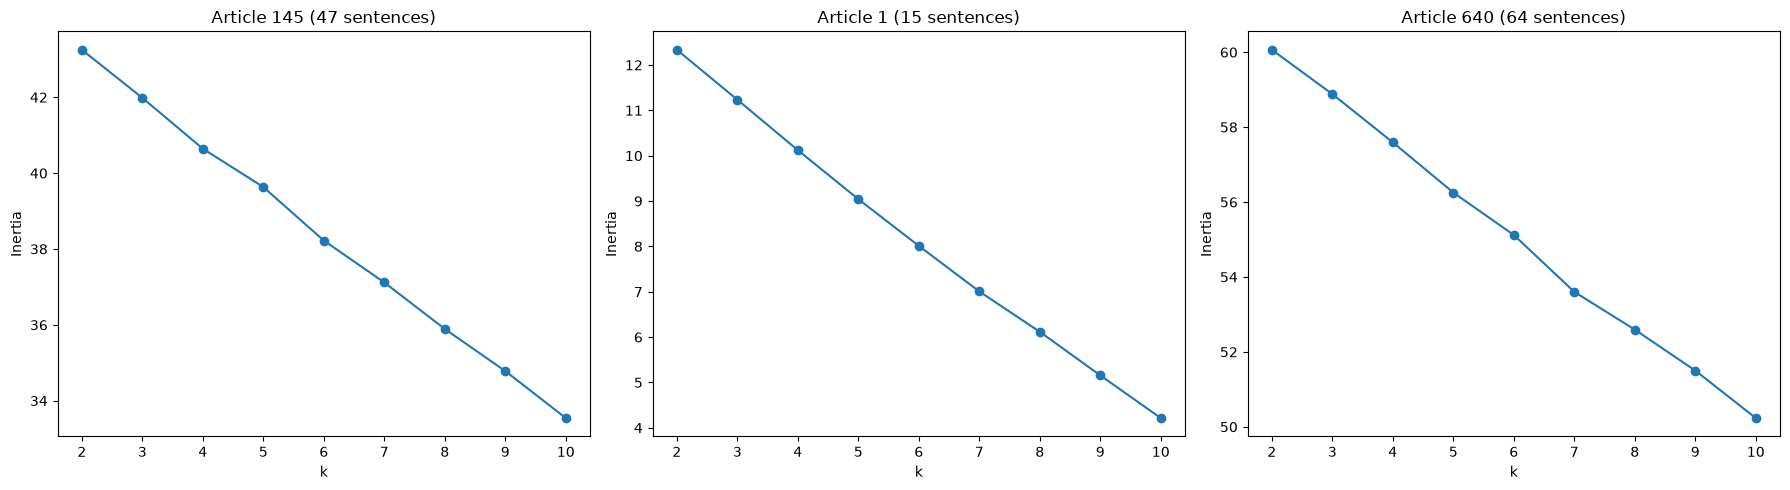

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, idx in zip(axes, test_indices):
    clean_sents = df.loc[idx, 'clean_sentences']
    vectorizer = TfidfVectorizer()
    tfidf_mat = vectorizer.fit_transform(clean_sents)
    
    inertias = []
    k_range = range(2, min(11, len(clean_sents)))  # don't exceed number of sentences
    
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(tfidf_mat)
        inertias.append(km.inertia_)
    
    ax.plot(k_range, inertias, marker='o')
    ax.set_xlabel('k')
    ax.set_ylabel('Inertia')
    ax.set_title(f'Article {idx} ({len(clean_sents)} sentences)')

plt.tight_layout()
plt.show()


## 13. K-Means Extractive Summarization Implementation

For the final summarization implementation, the number of clusters *k* was set equal
to the desired summary length (`num_sentences`), ensuring each cluster contributes
exactly one sentence to the output. For each cluster, the member sentence closest
(by Euclidean distance) to the cluster centroid was selected as its representative.
This design inherently promotes topical diversity, as near-duplicate sentences are
grouped into the same cluster and therefore contribute only a single representative to
the final summary.


In [28]:
def kmeans_summarize(article_idx, df, num_sentences=3):
    clean_sents = df.loc[article_idx, 'clean_sentences']
    original_sents = df.loc[article_idx, 'sentences']
    
    # can't have more clusters than sentences
    k = min(num_sentences, len(clean_sents))
    
    vectorizer = TfidfVectorizer()
    tfidf_mat = vectorizer.fit_transform(clean_sents)
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(tfidf_mat)
    
    selected_idxs = []
    for cluster_id in range(k):
        # indices of sentences in this cluster
        member_idxs = [i for i, label in enumerate(cluster_labels) if label == cluster_id]
        
        # find the member closest to this cluster's centroid
        centroid = km.cluster_centers_[cluster_id]
        member_vectors = tfidf_mat[member_idxs]
        distances = np.linalg.norm(member_vectors.toarray() - centroid, axis=1)
        closest_member = member_idxs[np.argmin(distances)]
        
        selected_idxs.append(closest_member)
    
    # order by original position so the summary reads coherently
    selected_idxs = sorted(selected_idxs)
    
    return [original_sents[i] for i in selected_idxs]

In [29]:
print("K-MEANS SUMMARY:")
kmeans_summary = kmeans_summarize(longer_idx, df, num_sentences=3)
for s in kmeans_summary:
    print("-", s)


K-MEANS SUMMARY:
- The economic targets set out at the Lisbon summit of European Union leaders in 2000 were meant to help Europe leapfrog its way past the United States to become the world's leading economy by 2010.
- "What you find is that a lot of people have been fighting change.
- That's why the Kok report recommends that the Lisbon targets be narrowed down to 14 key indicators, with an emphasis on creating jobs and economic growth.


## 14. Method 4 - Agglomerative Hierarchical Clustering: Dendrogram Analysis

**Agglomerative hierarchical clustering** constructs a nested tree of clusters in a
bottom-up manner: each sentence begins as its own singleton cluster, and the two
closest clusters are iteratively merged until a single cluster remains. **Ward
linkage** was used, which merges clusters at each step so as to minimize the resulting
increase in within-cluster variance - a criterion conceptually aligned with the
objective optimized by K-Means, making it a natural pairing with TF-IDF vector
representations.

The merge history is visualized as a **dendrogram**, in which the height of each merge
reflects the dissimilarity between the merged clusters. This visualization supports
selection of an appropriate cut point to yield a target number of clusters.


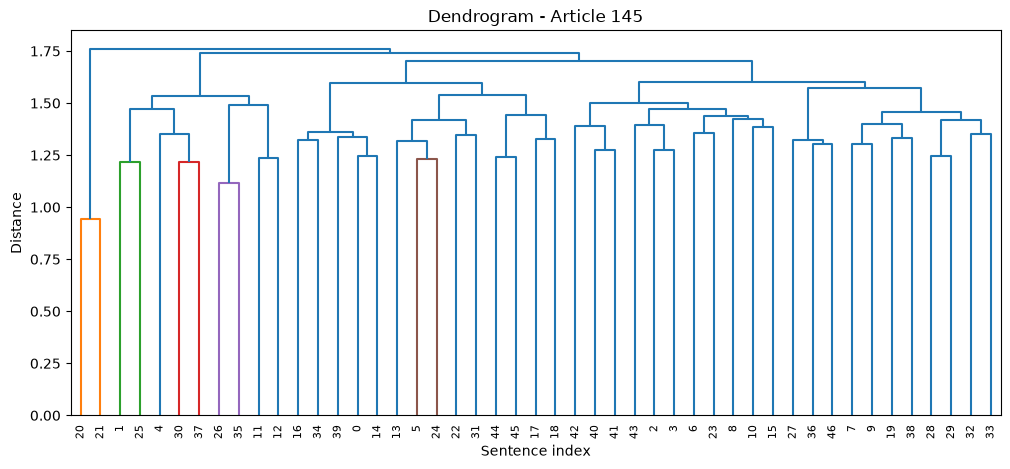

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage

clean_sents = df.loc[longer_idx, 'clean_sentences']

vectorizer = TfidfVectorizer()
tfidf_mat = vectorizer.fit_transform(clean_sents)

# 'ward' linkage minimizes within-cluster variance, similar in spirit to K-Means
Z = linkage(tfidf_mat.toarray(), method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title(f'Dendrogram - Article {longer_idx}')
plt.xlabel('Sentence index')
plt.ylabel('Distance')
plt.show()

## 15. Hierarchical Clustering Extractive Summarization Implementation

The dendrogram was cut using `fcluster` with the `maxclust` criterion to yield exactly
*k* clusters, matching the cluster count convention used for K-Means (Section 13).
As Ward linkage does not directly provide cluster centroids, these were computed
manually as the mean feature vector of each cluster's members; the member sentence
closest to this computed centroid was selected as the cluster's representative
sentence, following the same selection logic applied in the K-Means implementation.


In [31]:
from scipy.cluster.hierarchy import fcluster

def hierarchical_summarize(article_idx, df, num_sentences=3):
    clean_sents = df.loc[article_idx, 'clean_sentences']
    original_sents = df.loc[article_idx, 'sentences']
    
    k = min(num_sentences, len(clean_sents))
    
    vectorizer = TfidfVectorizer()
    tfidf_mat = vectorizer.fit_transform(clean_sents)
    dense_mat = tfidf_mat.toarray()
    
    Z = linkage(dense_mat, method='ward')
    cluster_labels = fcluster(Z, t=k, criterion='maxclust')  # cuts tree into k clusters
    
    selected_idxs = []
    for cluster_id in np.unique(cluster_labels):
        member_idxs = [i for i, label in enumerate(cluster_labels) if label == cluster_id]
        
        # cluster "centroid" = mean of member vectors (Ward doesn't give us one directly, unlike KMeans)
        centroid = dense_mat[member_idxs].mean(axis=0)
        member_vectors = dense_mat[member_idxs]
        distances = np.linalg.norm(member_vectors - centroid, axis=1)
        closest_member = member_idxs[np.argmin(distances)]
        
        selected_idxs.append(closest_member)
    
    selected_idxs = sorted(selected_idxs)
    
    return [original_sents[i] for i in selected_idxs]

In [32]:
print("HIERARCHICAL SUMMARY:")
hier_summary = hierarchical_summarize(longer_idx, df, num_sentences=3)
for s in hier_summary:
    print("-", s)

HIERARCHICAL SUMMARY:
- Mr Kok was commissioned by the European Commission in March this year to assess how far the EU has come towards meeting the Lisbon targets, five years on from their inception.
- "What you find is that a lot of people have been fighting change.
- The European economic and social model needs to change, but not so much so that social and environmental issues take a backseat to economic growth.


## 16. Method 5 - DBSCAN: Parameter Selection via K-Distance Analysis

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) differs from
the preceding clustering methods in that it does not require the number of clusters to
be specified in advance. Instead, it identifies dense regions of points (sentences
with many close neighbors) as clusters, while designating points in sparse regions as
**noise**. This property is well-suited to sentence-level analysis, as not every
sentence in an article necessarily belongs to a coherent thematic cluster; some
sentences are legitimately isolated or tangential.

DBSCAN requires two parameters: `min_samples` (minimum neighborhood size to form a
dense region) and `eps` (neighborhood radius). The **k-distance plot** - sorting, for
every point, its distance to its *k*-th nearest neighbor (here *k* = 4, matching
`min_samples = 4`) - was used to select an appropriate `eps` value. The point at which
this sorted distance curve exhibits a sharp increase indicates a natural density
threshold separating cluster members from noise; this analysis yielded `eps = 1.37`.


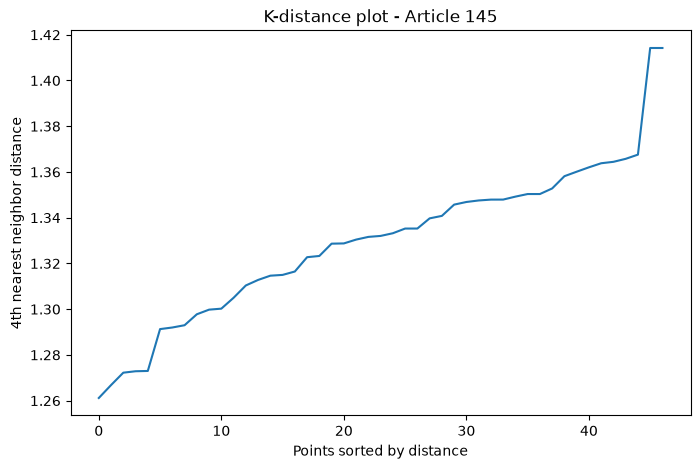

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

clean_sents = df.loc[longer_idx, 'clean_sentences']
vectorizer = TfidfVectorizer()
tfidf_mat = vectorizer.fit_transform(clean_sents)

# k-distance plot: for each point, distance to its 4th nearest neighbor (min_samples=4 convention)
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(tfidf_mat)
distances, indices = neighbors_fit.kneighbors(tfidf_mat)

# sort distances to the 4th neighbor, ascending
k_distances = np.sort(distances[:, 3])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('4th nearest neighbor distance')
plt.title(f'K-distance plot - Article {longer_idx}')
plt.show()


In [34]:
eps_value = 1.37  # just below the uptick

dbscan = DBSCAN(eps=eps_value, min_samples=4)
cluster_labels = dbscan.fit_predict(tfidf_mat)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Cluster labels: {cluster_labels}")

Number of clusters found: 1
Number of noise points: 1
Cluster labels: [ 0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


## 17. DBSCAN Extractive Summarization Implementation

The DBSCAN-based summarizer accounts for the possibility of noise points not assigned
to any cluster, through the following procedure:
1. Non-noise sentences are ranked by distance to their respective cluster centroid.
2. The closest sentences across all clusters are selected first, up to the target
   summary length.
3. If insufficient cluster members are available, noise points are used to fill the
   remaining summary positions, on the basis that isolated sentences may represent
   distinctive, standalone information rather than irrelevant content.
4. In the edge case where no clusters are identified (all points classified as noise),
   the method falls back to selecting the first *N* sentences by document order,
   ensuring robust output in all cases.


In [35]:
def dbscan_summarize(article_idx, df, num_sentences=3, eps=1.37, min_samples=4):
    clean_sents = df.loc[article_idx, 'clean_sentences']
    original_sents = df.loc[article_idx, 'sentences']
    
    vectorizer = TfidfVectorizer()
    tfidf_mat = vectorizer.fit_transform(clean_sents)
    dense_mat = tfidf_mat.toarray()
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(dense_mat)
    
    noise_idxs = [i for i, label in enumerate(cluster_labels) if label == -1]
    cluster_ids = [c for c in np.unique(cluster_labels) if c != -1]
    
    selected_idxs = []
    
    if len(cluster_ids) == 0:
        # everything is noise — fall back to just returning the first num_sentences
        selected_idxs = list(range(min(num_sentences, len(clean_sents))))
    else:
        # rank every non-noise point by distance from its own cluster's centroid,
        # pick the closest ones first, across clusters, until we hit num_sentences
        ranked = []
        for cluster_id in cluster_ids:
            member_idxs = [i for i, label in enumerate(cluster_labels) if label == cluster_id]
            centroid = dense_mat[member_idxs].mean(axis=0)
            member_vectors = dense_mat[member_idxs]
            distances = np.linalg.norm(member_vectors - centroid, axis=1)
            for idx, dist in zip(member_idxs, distances):
                ranked.append((dist, idx))
        
        ranked.sort(key=lambda x: x[0])
        selected_idxs = [idx for _, idx in ranked[:num_sentences]]
        
        # if the cluster(s) didn't have enough members, top up with noise points
        # (treated as distinctive/salient rather than discarded)
        if len(selected_idxs) < num_sentences and noise_idxs:
            remaining = num_sentences - len(selected_idxs)
            selected_idxs.extend(noise_idxs[:remaining])
    
    selected_idxs = sorted(set(selected_idxs))
    
    return [original_sents[i] for i in selected_idxs]

In [36]:
print("DBSCAN SUMMARY:")
dbscan_summary = dbscan_summarize(longer_idx, df, num_sentences=3)
for s in dbscan_summary:
    print("-", s)

DBSCAN SUMMARY:
- Mr Kok was commissioned by the European Commission in March this year to assess how far the EU has come towards meeting the Lisbon targets, five years on from their inception.
- "Lisbon is about everything and thus about nothing," the Kok report said.
- That's why the Kok report recommends that the Lisbon targets be narrowed down to 14 key indicators, with an emphasis on creating jobs and economic growth.


## 18. Train-Test Split for Supervised Learning Methods

The five methods presented above (Sections 9-17) are unsupervised: they require no
labeled training data. The supervised classification methods presented in the
following sections (Naive Bayes, Decision Tree, K-Nearest Neighbors) require labeled
training examples, and their evaluation requires held-out data unseen during training
to obtain an unbiased estimate of generalization performance.

Accordingly, the dataset was partitioned at the article level into training (80%) and
test (20%) subsets using random sampling (`train_test_split`, fixed random seed for
reproducibility). All supervised models in this study are trained exclusively on the
training subset and evaluated exclusively on the test subset.


In [39]:
from sklearn.model_selection import train_test_split

article_indices = df.index.tolist()
train_idx, test_idx = train_test_split(article_indices, test_size=0.2, random_state=42)

print(f"Train articles: {len(train_idx)}, Test articles: {len(test_idx)}")

Train articles: 1780, Test articles: 445


## 19. Weak Supervision: Sentence Relevance Labeling

The BBC News Summary dataset provides document-level reference summaries but not
sentence-level relevance annotations, which are required to train the supervised
classifiers used in this study. A **weak supervision** approach was therefore adopted
to construct sentence-level labels programmatically: for each sentence in an article,
its maximum TF-IDF cosine similarity to any sentence in the corresponding reference
summary was computed. Sentences exceeding a similarity threshold of 0.3 were labeled
as relevant (1); all others were labeled as not relevant (0).

This labeling procedure was applied to the training and test article sets separately
to construct labeled sentence-level datasets. It is acknowledged as a methodological
limitation that these labels are heuristically derived rather than manually annotated,
and that classifier performance is consequently bounded by the quality of this
labeling proxy - a point addressed further in the discussion section of this report.


In [40]:
def label_sentences(article_idx, df, threshold=0.3):
    clean_sents = df.loc[article_idx, 'clean_sentences']
    ref_summary = df.loc[article_idx, 'summary']  # adjust column name if yours differs
    
    ref_sents = sent_tokenize(ref_summary)  # or however you tokenized reference summaries
    
    vectorizer = TfidfVectorizer()
    all_text = list(clean_sents) + list(ref_sents)
    tfidf_mat = vectorizer.fit_transform(all_text)
    
    n_article = len(clean_sents)
    article_vecs = tfidf_mat[:n_article]
    ref_vecs = tfidf_mat[n_article:]
    
    sims = cosine_similarity(article_vecs, ref_vecs)  # shape: (n_article_sents, n_ref_sents)
    max_sims = sims.max(axis=1)
    
    labels = (max_sims > threshold).astype(int)
    return labels

In [41]:
sample_labels = label_sentences(longer_idx, df, threshold=0.3)
print(sample_labels)
print("Relevant:", sample_labels.sum(), "/ Total:", len(sample_labels))

[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0]
Relevant: 4 / Total: 47


In [42]:
ref_summary = df.loc[longer_idx, 'summary']
ref_sents = sent_tokenize(ref_summary)
print("Reference summary sentence count:", len(ref_sents))

Reference summary sentence count: 6


In [43]:
def build_labeled_dataset(indices, df, threshold=0.3):
    all_rows = []
    for article_idx in indices:
        clean_sents = df.loc[article_idx, 'clean_sentences']
        original_sents = df.loc[article_idx, 'sentences']
        labels = label_sentences(article_idx, df, threshold=threshold)
        
        for i, (sent, label) in enumerate(zip(original_sents, labels)):
            all_rows.append({
                'article_idx': article_idx,
                'sentence_idx': i,
                'sentence': sent,
                'label': label
            })
    
    return pd.DataFrame(all_rows)

train_labels_df = build_labeled_dataset(train_idx, df, threshold=0.3)
print(f"Total sentences in training set: {len(train_labels_df)}")
print()
print(train_labels_df['label'].value_counts())
print()
print(f"Relevant ratio: {train_labels_df['label'].mean():.3f}")

Total sentences in training set: 32953

label
0    28876
1     4077
Name: count, dtype: int64

Relevant ratio: 0.124


## 20. Construction of the Labeled Feature Dataset

The sentence-level relevance labels (Section 19) were merged with the previously
computed structural and semantic features (`position`, `length`, `centroid_sim`,
`title_sim`; Section 8) on the composite key `(article_idx, position)`, producing a
complete labeled dataset suitable for supervised model training. Index alignment
between the two source tables was explicitly verified prior to merging, as any
misalignment at this stage would silently corrupt all downstream classification
results without raising an error.


In [44]:
print(features_df.columns.tolist())
print(features_df.head(3))

['position', 'length', 'centroid_sim', 'title_sim', 'article_idx']
   position  length  centroid_sim  title_sim  article_idx
0         0      12      0.333610   0.046794            0
1         1      13      0.275657   0.154453            0
2         2       8      0.486919   0.109930            0


In [45]:
# confirm position resets per article and matches sentence order
print(features_df[features_df['article_idx'] == 0]['position'].tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [46]:
train_data = train_labels_df.merge(
    features_df,
    left_on=['article_idx', 'sentence_idx'],
    right_on=['article_idx', 'position'],
    how='left'
)

print(train_data.shape)
print(train_data.isnull().sum())
train_data.head()

(32953, 8)
article_idx     0
sentence_idx    0
sentence        0
label           0
position        0
length          0
centroid_sim    0
title_sim       0
dtype: int64


,article_idx,sentence_idx,sentence,label,position,length,centroid_sim,title_sim
0,1490,0,Ashley Cole has refused to blame Robin van Per...,1,0,18,0.343101,0.313310
1,1490,1,Van Persie is suspended alongside Dennis Bergk...,0,1,14,0.287374,0.189832
2,1490,2,Thierry Henry is ruled out with an Achilles te...,0,2,12,0.327592,0.172653
3,1490,3,"""It's just something that happens on the spur ...",0,3,4,0.231206,0.000000
4,1490,4,"Cole added: ""I've done it before and I hope th...",0,4,8,0.350158,0.221111


## 21. Method 6 - Gaussian Naive Bayes Classification

**Gaussian Naive Bayes** is a probabilistic classifier derived from Bayes' theorem
under the simplifying assumption that all input features are conditionally
independent given the class label, and that each feature is normally distributed
within each class. Although the independence assumption is not strictly satisfied by
the engineered features (e.g., `centroid_sim` and `title_sim` are correlated), Naive
Bayes is computationally efficient and frequently performs competitively as a
baseline classifier.

The model was trained on the labeled training set and evaluated on the held-out test
set using accuracy, precision, recall, F1-score, and a confusion matrix - a standard
evaluation suite for binary classification that provides a more complete performance
picture than accuracy alone, particularly under class imbalance.


In [47]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# build test set the same way as train
test_labels_df = build_labeled_dataset(test_idx, df, threshold=0.3)
test_data = test_labels_df.merge(
    features_df,
    left_on=['article_idx', 'sentence_idx'],
    right_on=['article_idx', 'position'],
    how='left'
)

feature_cols = ['position', 'length', 'centroid_sim', 'title_sim']

X_train = train_data[feature_cols]
y_train = train_data['label']
X_test = test_data[feature_cols]
y_test = test_data['label']

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("NAIVE BAYES RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1:", f1_score(y_test, y_pred_nb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy: 0.8563313609467456
Precision: 0.36605890603085556
Recall: 0.25513196480938416
F1: 0.30069124423963134

Confusion Matrix:
[[6975  452]
 [ 762  261]]


## 22. Method 7 - Decision Tree Classification, with Overfitting Analysis

**Decision Tree classification** learns a hierarchy of feature-based decision rules
by recursively partitioning the training data to maximize class separation at each
split. Unlike Naive Bayes, this method makes no independence assumption between
features and can model feature interactions directly.

An unconstrained decision tree was first trained and evaluated, followed by an
explicit comparison of training-set versus test-set performance to detect
**overfitting** - indicated by substantially higher training performance relative to
test performance, reflecting the model's tendency to memorize training-set noise when
grown without depth constraints. A pruned variant (`max_depth = 5`) was subsequently
trained and evaluated using the same procedure, to assess whether depth restriction
reduces the train-test performance gap while maintaining acceptable test accuracy.


In [48]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("DECISION TREE RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

DECISION TREE RESULTS
Accuracy: 0.8299408284023668
Precision: 0.30868761552680224
Recall: 0.32649071358748777
F1: 0.3173396674584323

Confusion Matrix:
[[6679  748]
 [ 689  334]]


In [49]:
y_pred_train_dt = dt_model.predict(X_train)
print("Training accuracy:", accuracy_score(y_train, y_pred_train_dt))
print("Training F1:", f1_score(y_train, y_pred_train_dt))

Training accuracy: 1.0
Training F1: 1.0


In [50]:
dt_model_pruned = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model_pruned.fit(X_train, y_train)

y_pred_dt_pruned = dt_model_pruned.predict(X_test)
y_pred_train_dt_pruned = dt_model_pruned.predict(X_train)

print("DECISION TREE (max_depth=5) — TEST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_pruned))
print("Precision:", precision_score(y_test, y_pred_dt_pruned))
print("Recall:", recall_score(y_test, y_pred_dt_pruned))
print("F1:", f1_score(y_test, y_pred_dt_pruned))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_pruned))
print()
print("DECISION TREE (max_depth=5) — TRAINING RESULTS (for overfitting comparison)")
print("Training Accuracy:", accuracy_score(y_train, y_pred_train_dt_pruned))
print("Training F1:", f1_score(y_train, y_pred_train_dt_pruned))

DECISION TREE (max_depth=5) — TEST RESULTS
Accuracy: 0.878698224852071
Precision: 0.49107142857142855
Recall: 0.053763440860215055
F1: 0.09691629955947137

Confusion Matrix:
[[7370   57]
 [ 968   55]]

DECISION TREE (max_depth=5) — TRAINING RESULTS (for overfitting comparison)
Training Accuracy: 0.880496464661791
Training F1: 0.1375383267630311


## 23. Method 8 - K-Nearest Neighbors Classification

**K-Nearest Neighbors (KNN)** is an instance-based classification method that
assigns a class label to a new observation based on a majority vote among its *k*
nearest neighbors (here, *k* = 5) in feature space, measured by Euclidean distance.

Because KNN relies directly on distance computations across all input features,
feature scaling is required prior to training: without standardization, features with
larger numeric ranges (e.g., `position`) would disproportionately dominate the
distance metric relative to features on smaller scales (e.g., `centroid_sim`),
independent of their actual discriminative value. `StandardScaler` was applied to
standardize all features to zero mean and unit variance prior to fitting the KNN
model. This preprocessing step was not required for the Naive Bayes or Decision Tree
classifiers, as neither method computes distances directly.


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN (k=5) RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN (k=5) RESULTS
Accuracy: 0.8688757396449704
Precision: 0.39856801909307876
Recall: 0.16324535679374388
F1: 0.231622746185853

Confusion Matrix:
[[7175  252]
 [ 856  167]]


## 24. Method 9 - Abstractive Summarization with a Pretrained BART Model

All preceding methods (Sections 9-23) are **extractive**: they construct summaries by
selecting and concatenating verbatim sentences from the source article. This section
introduces an **abstractive** approach using **BART** (Bidirectional and
Auto-Regressive Transformers), a sequence-to-sequence deep learning model capable of
generating novel summary text that may paraphrase or synthesize information across
multiple source sentences, more closely approximating human summarization behavior.

The pretrained model `facebook/bart-large-cnn` - fine-tuned specifically for news
summarization on the CNN/DailyMail corpus - was used for inference only; no model
training was performed within this project. Key implementation parameters:

- **Device selection**: GPU (CUDA) used when available, with automatic fallback to
  CPU, affecting inference speed substantially.
- **`max_input_len = 1024`**: BART imposes a fixed maximum input sequence length (in
  subword tokens); longer articles are truncated, which constitutes a known limitation
  for lengthy source documents.
- **`num_beams = 4`**: beam search decoding, which explores multiple candidate output
  sequences in parallel and retains the highest-scoring one, generally improving
  output quality relative to greedy decoding at increased computational cost.

BART-generated summaries were produced for every article in the dataset and stored for
subsequent evaluation.


In [52]:
!pip install transformers torch --quiet

import torch
from transformers import BartForConditionalGeneration, BartTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_name = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(model_name)
bart_model = BartForConditionalGeneration.from_pretrained(model_name).to(device)
bart_model.eval()


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cuda


e:\Sign_Train_First\myenv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|███████

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [53]:
def generate_bart_summary(article_text, tokenizer, model, device, max_input_len=1024, max_output_len=142, min_output_len=30):
    inputs = tokenizer(
        article_text,
        max_length=max_input_len,
        truncation=True,
        return_tensors="pt"
    ).to(device)
    
    summary_ids = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_output_len,
        min_length=min_output_len,
        num_beams=4,
        early_stopping=True
    )
    
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# quick test on one article before running the full set
test_summary = generate_bart_summary(df.iloc[0]['article'], tokenizer, bart_model, device)
print("BART SUMMARY (test):")
print(test_summary)
print()
print("REFERENCE SUMMARY:")
print(df.iloc[0]['summary'])

BART SUMMARY (test):
Time Warner profits up 76% to $1.13bn for the three months to December. Firm now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes.

REFERENCE SUMMARY:
TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.It lost 464,000 subscribers in the fourth quarter profits were lower than in 

In [54]:
from tqdm import tqdm

bart_summaries = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    summary = generate_bart_summary(row['article'], tokenizer, bart_model, device)
    bart_summaries.append(summary)

df['bart_summary'] = bart_summaries

print("Done. Sample:")
print(df.iloc[0]['bart_summary'])

100%|██████████| 2225/2225 [23:56<00:00,  1.55it/s]

Done. Sample:
Time Warner profits up 76% to $1.13bn for the three months to December. Firm now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes.


## 25. Evaluation Metric: ROUGE

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) is the standard
automatic evaluation metric for text summarization, measuring n-gram overlap between a
generated summary and a human-authored reference summary. Three variants were
computed:

- **ROUGE-1**: unigram (individual word) overlap.
- **ROUGE-2**: bigram (consecutive word-pair) overlap, capturing preservation of local
  phrasing.
- **ROUGE-L**: overlap based on the Longest Common Subsequence, capturing preservation
  of word order while tolerating non-contiguous matches.

Each variant is reported in terms of precision, recall, and F1-score, with F1-score
used as the primary summary statistic throughout this study.

It is noted as a limitation of this metric that ROUGE measures lexical overlap rather
than semantic accuracy, and that this may systematically favor extractive methods
(which reuse source wording verbatim) over the abstractive BART method (which
paraphrases by design), a consideration addressed further in the results discussion.


In [55]:
!pip install rouge-score --quiet

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_rouge(reference, generated):
    scores = scorer.score(reference, generated)
    return {
        'rouge1_f': scores['rouge1'].fmeasure,
        'rouge2_f': scores['rouge2'].fmeasure,
        'rougeL_f': scores['rougeL'].fmeasure,
    }

bart_rouge = df.apply(lambda row: compute_rouge(row['summary'], row['bart_summary']), axis=1)
bart_rouge_df = pd.DataFrame(list(bart_rouge))

print("BART ROUGE SCORES (mean across all articles)")
print(bart_rouge_df.mean())


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


BART ROUGE SCORES (mean across all articles)
rouge1_f    0.295033
rouge2_f    0.196127
rougeL_f    0.224899
dtype: float64


## 26. Comparative Evaluation of All Summarization Methods

A generalized evaluation procedure (`evaluate_method_rouge`) was implemented to
compute ROUGE scores for any summarizer function against the full dataset, given a
uniform calling interface. To ensure a fair comparison across methods, the requested
summary length for each article was set equal to the sentence count of that article's
own reference summary, rather than a fixed length - preventing systematic ROUGE
recall penalties for summaries produced shorter than the reference. This procedure
was applied to all five unsupervised extractive methods and to BART, and the
resulting mean ROUGE-1/2/L scores were consolidated into a single comparative summary
table, constituting the principal quantitative result of this study.


In [56]:
def get_ref_sentence_count(article_idx, df):
    ref_summary = df.loc[article_idx, 'summary']
    return len(sent_tokenize(ref_summary))

def evaluate_method_rouge(summarize_fn, df, indices, **kwargs):
    results = []
    for article_idx in tqdm(indices):
        n = get_ref_sentence_count(article_idx, df)
        n = max(n, 1)  # safety: at least 1 sentence
        
        summary_sents = summarize_fn(article_idx, df, num_sentences=n, **kwargs)
        generated = " ".join(summary_sents)
        reference = df.loc[article_idx, 'summary']
        
        scores = compute_rouge(reference, generated)
        results.append(scores)
    
    return pd.DataFrame(results)

In [57]:
# Precompute reference sentence counts once instead of re-tokenizing inside the loop every method run
df['ref_sent_count'] = df['summary'].apply(lambda s: max(len(sent_tokenize(s)), 1))

def get_ref_sentence_count(article_idx, df):
    return df.loc[article_idx, 'ref_sent_count']

In [65]:
all_idx = df.index.tolist()

tfidf_rouge    = evaluate_method_rouge(tfidf_summarize_wrapper, df, all_idx)
textrank_rouge = evaluate_method_rouge(textrank_summarize,      df, all_idx)
kmeans_rouge   = evaluate_method_rouge(kmeans_summarize,        df, all_idx)
hier_rouge     = evaluate_method_rouge(hierarchical_summarize,  df, all_idx)
dbscan_rouge   = evaluate_method_rouge(dbscan_summarize,        df, all_idx)

summary_table = pd.DataFrame({
    'TF-IDF':       tfidf_rouge.mean(),
    'TextRank':     textrank_rouge.mean(),
    'K-Means':      kmeans_rouge.mean(),
    'Hierarchical': hier_rouge.mean(),
    'DBSCAN':       dbscan_rouge.mean(),
    'BART':         bart_rouge_df.mean(),
}).T

print(summary_table)

100%|██████████| 2225/2225 [00:29<00:00, 74.29it/s]

              rouge1_f  rouge2_f  rougeL_f
TF-IDF        0.409937  0.392536  0.349807
TextRank      0.412774  0.395473  0.351720
K-Means       0.360734  0.321341  0.312067
Hierarchical  0.366607  0.330510  0.317148
DBSCAN        0.403804  0.384398  0.344374
BART          0.295033  0.196127  0.224899


## 27. Diagnostic Analysis: Extractive Nature of Reference Summaries

A supplementary diagnostic analysis was performed to determine the proportion of
reference-summary sentences that appear verbatim within the corresponding source
article. This diagnostic is relevant to the interpretation of the comparative results
in Section 26: if reference summaries are themselves highly extractive in composition,
this would systematically favor extractive methods on the ROUGE metric relative to the
abstractive BART method, which generates paraphrased rather than verbatim text.

An initial implementation using strict, whitespace-stripped exact string matching
(likely underestimating true overlap due to minor formatting differences) was refined
into a second version employing more permissive whitespace normalization and substring
matching against the full article text, yielding a more accurate overlap estimate.


In [66]:
def extractive_overlap_fraction(article_idx, df):
    ref_sents = sent_tokenize(df.loc[article_idx, 'summary'])
    article_sents = df.loc[article_idx, 'sentences']
    matches = sum(1 for rs in ref_sents if rs.strip() in [a.strip() for a in article_sents])
    return matches / len(ref_sents) if ref_sents else 0

fractions = [extractive_overlap_fraction(i, df) for i in df.index]
print(pd.Series(fractions).describe())


count    2225.000000
mean        0.096929
std         0.189317
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
dtype: float64


In [67]:
import re

def normalize(s):
    return re.sub(r'\s+', ' ', s).strip()

def extractive_overlap_fraction_v2(article_idx, df):
    ref_sents = sent_tokenize(df.loc[article_idx, 'summary'])
    article_text = normalize(df.loc[article_idx, 'article'])
    matches = sum(1 for rs in ref_sents if normalize(rs) in article_text)
    return matches / len(ref_sents) if ref_sents else 0

fractions_v2 = [extractive_overlap_fraction_v2(i, df) for i in df.index]
print(pd.Series(fractions_v2).describe())

count    2225.000000
mean        0.134664
std         0.216175
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
dtype: float64


In [68]:
df['bart_summary_len'] = df['bart_summary'].apply(lambda s: len(sent_tokenize(s)))
df['ref_summary_len']  = df['summary'].apply(lambda s: len(sent_tokenize(s)))
print(df[['bart_summary_len', 'ref_summary_len']].describe())

       bart_summary_len  ref_summary_len
count       2225.000000      2225.000000
mean           2.710562         2.080000
std            0.563265         1.487018
min            1.000000         1.000000
25%            2.000000         1.000000
50%            3.000000         2.000000
75%            3.000000         3.000000
max            4.000000        11.000000


In [69]:
import re

def normalize(s):
    return re.sub(r'\s+', ' ', s).strip()

def extractive_overlap_fraction_v2(article_idx, df):
    ref_sents = sent_tokenize(df.loc[article_idx, 'summary'])
    article_text = normalize(df.loc[article_idx, 'article'])
    matches = sum(1 for rs in ref_sents if normalize(rs) in article_text)
    return matches / len(ref_sents) if ref_sents else 0

fractions_v2 = [extractive_overlap_fraction_v2(i, df) for i in df.index]
print(pd.Series(fractions_v2).describe())

count    2225.000000
mean        0.134664
std         0.216175
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
dtype: float64


## 28. Stratified Analysis of BART Performance by Reference Summary Length

To further investigate factors affecting BART's ROUGE performance, precision, recall,
and F1-score were computed and analyzed as a function of reference summary length
(stratified into buckets of 1, 2, 3, and 4+ sentences). This analysis addresses the
hypothesis that shorter reference summaries mechanically constrain achievable recall
for any generated summary, irrespective of summarization quality, and provides a
more granular basis for interpreting BART's aggregate ROUGE performance beyond a
single overall average.


In [70]:
def bart_precision_recall(row):
    s = scorer.score(row['summary'], row['bart_summary'])
    return pd.Series({'bart_r1_p': s['rouge1'].precision, 'bart_r1_r': s['rouge1'].recall})

pr = df.apply(bart_precision_recall, axis=1)
df = pd.concat([df, pr], axis=1)

print(df[['bart_r1_p', 'bart_r1_r']].mean())

# does BART's score depend on how short the reference is?
df['ref_len_bucket'] = pd.cut(df['ref_summary_len'], bins=[0,1,2,3,100], labels=['1','2','3','4+'])
print(df.groupby('ref_len_bucket').apply(lambda g: scorer.score(g['summary'].iloc[0], g['bart_summary'].iloc[0])))

bart_r1_p    0.735118
bart_r1_r    0.192799
dtype: float64
ref_len_bucket
1     {'rouge1': (0.59375, 0.12418300653594772, 0.20...
2     {'rouge1': (0.75, 0.18461538461538463, 0.29629...
3     {'rouge1': (0.6521739130434783, 0.088235294117...
4+    {'rouge1': (0.6666666666666666, 0.226415094339...
dtype: object


In [71]:
df['bart_r1_f'] = df.apply(lambda r: scorer.score(r['summary'], r['bart_summary'])['rouge1'].fmeasure, axis=1)
print(df.groupby('ref_len_bucket')['bart_r1_f'].agg(['mean', 'count']))

                    mean  count
ref_len_bucket                 
1               0.322507   1094
2               0.297817    517
3               0.253043    284
4+              0.235724    330


In [72]:
df['bart_r1_f'] = df.apply(lambda r: scorer.score(r['summary'], r['bart_summary'])['rouge1'].fmeasure, axis=1)

def bart_precision_recall(row):
    s = scorer.score(row['summary'], row['bart_summary'])
    return pd.Series({'bart_r1_p': s['rouge1'].precision, 'bart_r1_r': s['rouge1'].recall})

pr = df.apply(bart_precision_recall, axis=1)
df = pd.concat([df, pr], axis=1)

print(df[['bart_r1_p', 'bart_r1_r']].mean())

df['ref_len_bucket'] = pd.cut(df['ref_summary_len'], bins=[0,1,2,3,100], labels=['1','2','3','4+'])
print(df.groupby('ref_len_bucket')['bart_r1_f'].agg(['mean', 'count']))

bart_r1_p    0.735118
bart_r1_p    0.735118
bart_r1_r    0.192799
bart_r1_r    0.192799
dtype: float64
                    mean  count
ref_len_bucket                 
1               0.322507   1094
2               0.297817    517
3               0.253043    284
4+              0.235724    330


## 29. Data Cleanup

Duplicate columns resulting from repeated execution of preceding analysis cells were
removed, retaining only the most recently computed values, to ensure data integrity
in subsequent steps.


In [73]:
df = df.loc[:, ~df.columns.duplicated(keep='last')]


## 30. Computational Runtime Comparison

In addition to output quality, computational efficiency was evaluated as a secondary
comparison criterion, since a marginal quality improvement may not justify a
substantially higher computational cost in practical deployment. Wall-clock runtime
was measured for each unsupervised extractive method across the full dataset, both in
total and average per-article terms.

BART runtime was measured separately on a representative 100-article sample rather
than the full dataset, in view of its substantially higher per-article computational
cost relative to the classical methods; the resulting average was extrapolated to
estimate total runtime across the complete dataset. This runtime comparison is
presented alongside the ROUGE results (Section 26) to support a holistic
quality-versus-cost evaluation of each method.


In [74]:
import time

def time_method(summarize_fn, df, indices, **kwargs):
    start = time.time()
    for article_idx in indices:
        n = get_ref_sentence_count(article_idx, df)
        n = max(n, 1)
        _ = summarize_fn(article_idx, df, num_sentences=n, **kwargs)
    elapsed = time.time() - start
    return elapsed, elapsed / len(indices)

methods = {
    'TF-IDF':       tfidf_summarize_wrapper,
    'TextRank':     textrank_summarize,
    'K-Means':      kmeans_summarize,
    'Hierarchical': hierarchical_summarize,
    'DBSCAN':       dbscan_summarize,
}

runtime_results = {}
for name, fn in methods.items():
    total, per_article = time_method(fn, df, all_idx)
    runtime_results[name] = {'total_sec': total, 'sec_per_article': per_article}
    print(f"{name}: {total:.2f}s total, {per_article*1000:.2f}ms/article")

runtime_df = pd.DataFrame(runtime_results).T
print(runtime_df)

TF-IDF: 0.96s total, 0.43ms/article
TextRank: 5.44s total, 2.44ms/article
K-Means: 165.83s total, 74.53ms/article
Hierarchical: 2.92s total, 1.31ms/article
DBSCAN: 19.34s total, 8.69ms/article
               total_sec  sec_per_article
TF-IDF          0.956385         0.000430
TextRank        5.439698         0.002445
K-Means       165.832483         0.074531
Hierarchical    2.921540         0.001313
DBSCAN         19.341034         0.008693


In [75]:
# if you didn't time the original BART loop, re-run timing on a smaller sample
# rather than the full 2225 again — inference is the expensive part
import time
sample_idx = df.index[:100].tolist()

start = time.time()
for idx in sample_idx:
    _ = generate_bart_summary(df.loc[idx, 'article'], tokenizer, bart_model, device)
bart_elapsed = time.time() - start
bart_per_article = bart_elapsed / len(sample_idx)
print(f"BART: {bart_per_article*1000:.2f}ms/article (sampled on {len(sample_idx)} articles)")

runtime_df.loc['BART'] = {'total_sec': bart_per_article * len(all_idx), 'sec_per_article': bart_per_article}
print(runtime_df)

BART: 611.11ms/article (sampled on 100 articles)
                total_sec  sec_per_article
TF-IDF           0.956385         0.000430
TextRank         5.439698         0.002445
K-Means        165.832483         0.074531
Hierarchical     2.921540         0.001313
DBSCAN          19.341034         0.008693
BART          1359.723963         0.611112


## 31. Classifier-Based Summarization and Evaluation

To incorporate the supervised classifiers (Sections 21-23) into the summarization
comparison, a unified `classifier_summarize` procedure was implemented. Rather than
relying on each classifier's binary relevant/not-relevant prediction, the model's
predicted **probability** of relevance (via `predict_proba`) was used to rank all
sentences within an article, from which the top-N sentences were selected — consistent
with the ranking-based selection procedure used throughout the extractive methods in
this study.

Each trained classifier (Naive Bayes, pruned Decision Tree, KNN) was evaluated using
this procedure, restricted to the held-out **test article set** only. This restriction
is methodologically necessary: unlike the unsupervised methods, which were evaluated
across the full dataset, the supervised classifiers were exposed to training-set
labels during fitting, and evaluating them on training articles would produce an
inflated, non-generalizable performance estimate.


In [76]:
def classifier_summarize(article_idx, df, model, feature_cols, num_sentences=3, use_scaler=None):
    article_feats = features_df[features_df['article_idx'] == article_idx].copy()
    X = article_feats[feature_cols]
    if use_scaler is not None:
        X = use_scaler.transform(X)

    # predicted probability of being relevant (class 1), not just the hard 0/1 label —
    # this lets us rank sentences even when the model predicts all-0 or more than num_sentences 1s
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X)[:, 1]
    else:
        scores = model.predict(X)

    article_feats = article_feats.copy()
    article_feats['relevance_score'] = scores

    top_sentences = article_feats.sort_values('relevance_score', ascending=False).head(num_sentences)
    top_sentences = top_sentences.sort_values('position')

    original_sentences = df.loc[article_idx, 'sentences']
    return [original_sentences[i] for i in top_sentences['position']]

In [77]:
def dt_wrapper(article_idx, df, num_sentences=3):
    return classifier_summarize(article_idx, df, dt_model_pruned, feature_cols, num_sentences=num_sentences)

def knn_wrapper(article_idx, df, num_sentences=3):
    return classifier_summarize(article_idx, df, knn_model, feature_cols, num_sentences=num_sentences, use_scaler=scaler)

def nb_wrapper(article_idx, df, num_sentences=3):
    return classifier_summarize(article_idx, df, nb_model, feature_cols, num_sentences=num_sentences)

dt_rouge  = evaluate_method_rouge(dt_wrapper,  df, test_idx)
knn_rouge = evaluate_method_rouge(knn_wrapper, df, test_idx)
nb_rouge  = evaluate_method_rouge(nb_wrapper,  df, test_idx)

print(dt_rouge.mean())
print(knn_rouge.mean())
print(nb_rouge.mean())

100%|██████████| 445/445 [00:02<00:00, 185.07it/s]

rouge1_f    0.440300
rouge2_f    0.414359
rougeL_f    0.376041
dtype: float64
rouge1_f    0.383194
rouge2_f    0.338495
rougeL_f    0.321848
dtype: float64
rouge1_f    0.417013
rouge2_f    0.385971
rougeL_f    0.349922
dtype: float64


## Summary of Methods and Conclusion

| Category | Methods Implemented | Underlying Principle |
|---|---|---|
| Statistical / graph-based extractive | TF-IDF Centroid, TextRank | Sentence scoring based on vocabulary centrality or graph-based mutual reinforcement between sentences |
| Clustering-based extractive | K-Means, Agglomerative Hierarchical, DBSCAN | Grouping of sentences by sub-topic, with one representative sentence selected per cluster |
| Supervised classification-based extractive | Naive Bayes, Decision Tree, K-Nearest Neighbors | Learned prediction of sentence relevance from structural and semantic features, using weak-supervision labels |
| Abstractive (deep learning) | BART (pretrained transformer) | Generation of novel, paraphrased summary text via sequence-to-sequence modeling |
| Evaluation | ROUGE-1, ROUGE-2, ROUGE-L; computational runtime | Quantification of lexical overlap with reference summaries and computational cost per method |

This project implements and empirically evaluates nine distinct text summarization
methods spanning four methodological paradigms, using a consistent dataset, feature
set, and evaluation protocol across all methods. The comparative results (Section 26)
and runtime analysis (Section 30), together with the diagnostic analyses of reference
summary composition (Section 27) and BART performance stratification (Section 28),
provide a comprehensive empirical basis for assessing the relative strengths,
limitations, and practical trade-offs of statistical, clustering-based, supervised,
and deep learning-based approaches to automatic text summarization.
